# VerifAI 2.0 — Training from Scratch
**IE7374 — Generative AI | Northeastern University**  
Rosalina Torres | Custom Bilingual Transformer Classifier

---
**Before running:** Upload these 4 files from `~/verif-ai/` using the 📁 sidebar:
- `data/train.csv`
- `data/val.csv`
- `models/verifai-classifier/vocab.json`
- `model/tokenizer.py`
- `model/architecture.py`
- `model/dataset.py`

Then **Runtime → Change runtime type → T4 GPU**, then Run All.

In [1]:
# ── Cell 1: Verify GPU ────────────────────────────────────────────
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: No GPU detected. Go to Runtime → Change runtime type → T4 GPU')

Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


In [2]:
# ── Cell 2: Install pyyaml (only missing dep on Colab) ────────────
import subprocess
subprocess.run(['pip', 'install', 'pyyaml', '-q'])
print('Dependencies ready.')

Dependencies ready.


In [3]:
# ── Cell 3b: Mount Google Drive for checkpoint backup ────────────
# Run this BEFORE training starts. Checkpoints auto-save to Drive
# so you never lose progress if Colab disconnects.
from google.colab import drive
drive.mount("/content/drive")

import os
DRIVE_BACKUP = "/content/drive/MyDrive/VerifAI_checkpoints"
os.makedirs(DRIVE_BACKUP, exist_ok=True)
print(f"Drive mounted. Checkpoints will also save to: {DRIVE_BACKUP}")


Mounted at /content/drive
Drive mounted. Checkpoints will also save to: /content/drive/MyDrive/VerifAI_checkpoints


In [4]:
# ── Cell 3: Verify uploaded files ────────────────────────────────
import os
required = ['train.csv', 'val.csv', 'vocab.json',
            'tokenizer.py', 'architecture.py', 'dataset.py']
missing = [f for f in required if not os.path.exists(f'/content/{f}')]
if missing:
    print(f'MISSING FILES — upload these to /content/: {missing}')
else:
    print('All files present. Ready to train.')

All files present. Ready to train.


In [5]:
# ── Cell 4: Setup paths and imports ──────────────────────────────
import sys, os, json, time, math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, classification_report

sys.path.insert(0, '/content')
from tokenizer import BPETokenizer
from architecture import VerifAIClassifier
from dataset import ClaimDataset, get_class_weights, LABEL2ID, ID2LABEL

# ── Config v3 — Run 1 architecture + label smoothing + early stopping
# Changes from Run 1:
#   label_smoothing 0→0.1    prevents overconfident predictions
#   early_stopping_patience=3  stops before overfitting
#   lr 1e-4→5e-5, warmup 500→1000  more stable training
#   num_epochs 10→15  more room to find best val F1
# Restored from Run 1 (Run 2 was too small):
#   num_layers=4, embed_dim=256, hidden_dim=512, dropout=0.1
CONFIG = {
    'vocab_size':             16000,
    'embed_dim':              256,    # restored from Run 1
    'num_heads':              8,
    'num_layers':             4,      # restored from Run 1
    'hidden_dim':             512,    # restored from Run 1
    'max_length':             256,
    'num_labels':             4,
    'dropout':                0.1,    # restored from Run 1
    'batch_size':             32,
    'learning_rate':          5e-5,   # kept from Run 2
    'warmup_steps':           1000,   # kept from Run 2
    'num_epochs':             15,
    'weight_decay':           0.01,
    'gradient_clip':          1.0,
    'label_smoothing':        0.1,    # NEW — prevents overconfident predictions
    'early_stopping_patience': 3,     # NEW — stop if val F1 doesn't improve
    'seed':                   42,
}

torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Config v3 loaded. Device: {device}')
print('Run 1 architecture + label_smoothing=0.1 + early_stopping patience=3')


Config v3 loaded. Device: cuda
Run 1 architecture + label_smoothing=0.1 + early_stopping patience=3


In [6]:
# ── Cell 5: Load tokenizer and datasets ──────────────────────────
print('Loading tokenizer...')
tokenizer = BPETokenizer.load('/content/vocab.json')
print(f'Vocab size: {len(tokenizer)}')

print('\nLoading training dataset...')
train_ds = ClaimDataset('/content/train.csv', tokenizer, CONFIG['max_length'])

print('\nLoading validation dataset...')
val_ds = ClaimDataset('/content/val.csv', tokenizer, CONFIG['max_length'])

train_loader = DataLoader(
    train_ds,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=2,
    pin_memory=True
)
val_loader = DataLoader(
    val_ds,
    batch_size=CONFIG['batch_size'] * 2,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)
print(f'\nTrain batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')

Loading tokenizer...
Vocab size: 16000

Loading training dataset...
  Dataset loaded: 37608 examples
  Labels: {'false': 10687, 'true': 9798, 'misleading': 8574, 'unverifiable': 8549}
  Languages: {'en': 36617, 'es': 991}

Loading validation dataset...
  Dataset loaded: 3394 examples
  Labels: {'false': 1165, 'true': 1110, 'misleading': 876, 'unverifiable': 243}
  Languages: {'en': 3338, 'es': 56}

Train batches: 1176
Val batches:   54


In [7]:
# ── Cell 6: Initialize model ─────────────────────────────────────
print('Initializing VerifAIClassifier v3 (Run 1 arch + label smoothing)...')
model = VerifAIClassifier(
    vocab_size   = CONFIG['vocab_size'],
    embed_dim    = CONFIG['embed_dim'],
    num_heads    = CONFIG['num_heads'],
    num_layers   = CONFIG['num_layers'],
    hidden_dim   = CONFIG['hidden_dim'],
    max_length   = CONFIG['max_length'],
    num_classes  = CONFIG['num_labels'],
    dropout      = CONFIG['dropout'],
).to(device)

# Class-weighted loss WITH label smoothing
class_weights = get_class_weights('/content/train.csv').to(device)
print(f'Class weights: {class_weights}')
criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=CONFIG['label_smoothing']
)

# AdamW optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CONFIG['learning_rate'],
    weight_decay=CONFIG['weight_decay']
)

# Linear warmup + cosine decay
total_steps  = len(train_loader) * CONFIG['num_epochs']
warmup_steps = CONFIG['warmup_steps']

def lr_lambda(step):
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return max(0.05, 0.5 * (1.0 + math.cos(math.pi * progress)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
print(f'Total training steps: {total_steps:,}')
print(f'Warmup steps: {warmup_steps}')
print(f'Label smoothing: {CONFIG["label_smoothing"]}')
print(f'Early stopping patience: {CONFIG["early_stopping_patience"]} epochs')


Initializing VerifAIClassifier v3 (Run 1 arch + label smoothing)...
VerifAIClassifier initialized:
  Total parameters:     6,300,804
  Trainable parameters: 6,300,804
Class weights: tensor([0.9596, 0.8798, 1.0966, 1.0998], device='cuda:0')
Total training steps: 17,640
Warmup steps: 1000
Label smoothing: 0.1
Early stopping patience: 3 epochs


In [8]:
# ── Cell 7: Training and evaluation functions ─────────────────────

def train_epoch(model, loader, optimizer, scheduler, criterion, device, clip):
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0
    all_preds, all_labels = [], []

    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        language_ids   = batch['language_id'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask, language_ids)
        loss = criterion(logits, labels)
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        scheduler.step()

        preds = logits.argmax(dim=-1)
        total_loss    += loss.item() * len(labels)
        total_correct += (preds == labels).sum().item()
        total_samples += len(labels)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, accuracy, f1


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0
    all_preds, all_labels = [], []

    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        language_ids   = batch['language_id'].to(device)
        labels         = batch['label'].to(device)

        logits = model(input_ids, attention_mask, language_ids)
        loss = criterion(logits, labels)

        preds = logits.argmax(dim=-1)
        total_loss    += loss.item() * len(labels)
        total_correct += (preds == labels).sum().item()
        total_samples += len(labels)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, accuracy, f1, all_preds, all_labels


print('Training functions defined.')

Training functions defined.


In [9]:
# ── Cell 8: Training loop with early stopping ────────────────────
os.makedirs('/content/checkpoint', exist_ok=True)

training_log = []
best_val_f1   = 0.0
best_epoch    = 0
patience_counter = 0
PATIENCE = CONFIG['early_stopping_patience']

print('='*60)
print('VerifAI 2.0 — Training from Scratch (Run 3)')
print(f'Epochs: {CONFIG["num_epochs"]} | Batch: {CONFIG["batch_size"]} | LR: {CONFIG["learning_rate"]}')
print(f'Label smoothing: {CONFIG["label_smoothing"]} | Early stop patience: {PATIENCE}')
print('='*60)

for epoch in range(1, CONFIG['num_epochs'] + 1):
    t0 = time.time()

    train_loss, train_acc, train_f1 = train_epoch(
        model, train_loader, optimizer, scheduler,
        criterion, device, CONFIG['gradient_clip']
    )
    val_loss, val_acc, val_f1, val_preds, val_labels = evaluate(
        model, val_loader, criterion, device
    )

    elapsed = time.time() - t0
    lr_now  = scheduler.get_last_lr()[0]

    log_entry = {
        'epoch':      epoch,
        'train_loss': round(train_loss, 4),
        'train_acc':  round(train_acc,  4),
        'train_f1':   round(train_f1,   4),
        'val_loss':   round(val_loss,   4),
        'val_acc':    round(val_acc,    4),
        'val_f1':     round(val_f1,     4),
        'lr':         round(lr_now,     8),
        'elapsed_s':  round(elapsed,    1),
    }
    training_log.append(log_entry)

    print(f'Epoch {epoch:02d}/{CONFIG["num_epochs"]} '
          f'| train_loss={train_loss:.4f} train_f1={train_f1:.4f} '
          f'| val_loss={val_loss:.4f} val_f1={val_f1:.4f} '
          f'| lr={lr_now:.2e} | {elapsed:.0f}s')

    if val_f1 > best_val_f1:
        best_val_f1  = val_f1
        best_epoch   = epoch
        patience_counter = 0
        torch.save({
            'epoch':           epoch,
            'model_state':     model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'val_f1':          val_f1,
            'config':          CONFIG,
        }, '/content/checkpoint/best_model.pt')
        print(f'  ✅ New best checkpoint saved (val_f1={val_f1:.4f})')
        try:
            import shutil
            shutil.copy('/content/checkpoint/best_model.pt',
                        DRIVE_BACKUP + '/best_model.pt')
            print(f'  💾 Backed up to Drive')
        except Exception as e:
            print(f'  Drive backup skipped: {e}')
    else:
        patience_counter += 1
        print(f'  No improvement ({patience_counter}/{PATIENCE})')
        if patience_counter >= PATIENCE:
            print(f'  Early stopping triggered at epoch {epoch}.')
            break

with open('/content/checkpoint/training_log.json', 'w') as f:
    json.dump(training_log, f, indent=2)

print(f'\nTraining complete. Best val_f1={best_val_f1:.4f} at epoch {best_epoch}')


VerifAI 2.0 — Training from Scratch (Run 3)
Epochs: 15 | Batch: 32 | LR: 5e-05
Label smoothing: 0.1 | Early stop patience: 3
Epoch 01/15 | train_loss=1.3720 train_f1=0.2811 | val_loss=1.3596 val_f1=0.3009 | lr=5.00e-05 | 110s
  ✅ New best checkpoint saved (val_f1=0.3009)
  💾 Backed up to Drive
Epoch 02/15 | train_loss=1.3162 train_f1=0.3807 | val_loss=1.3256 val_f1=0.3386 | lr=4.92e-05 | 111s
  ✅ New best checkpoint saved (val_f1=0.3386)
  💾 Backed up to Drive
Epoch 03/15 | train_loss=1.2848 train_f1=0.4151 | val_loss=1.3175 val_f1=0.3713 | lr=4.72e-05 | 111s
  ✅ New best checkpoint saved (val_f1=0.3713)
  💾 Backed up to Drive
Epoch 04/15 | train_loss=1.2558 train_f1=0.4417 | val_loss=1.3555 val_f1=0.3595 | lr=4.41e-05 | 110s
  No improvement (1/3)
Epoch 05/15 | train_loss=1.2247 train_f1=0.4703 | val_loss=1.3102 val_f1=0.3876 | lr=4.01e-05 | 110s
  ✅ New best checkpoint saved (val_f1=0.3876)
  💾 Backed up to Drive
Epoch 06/15 | train_loss=1.1952 train_f1=0.4954 | val_loss=1.3467 val_f

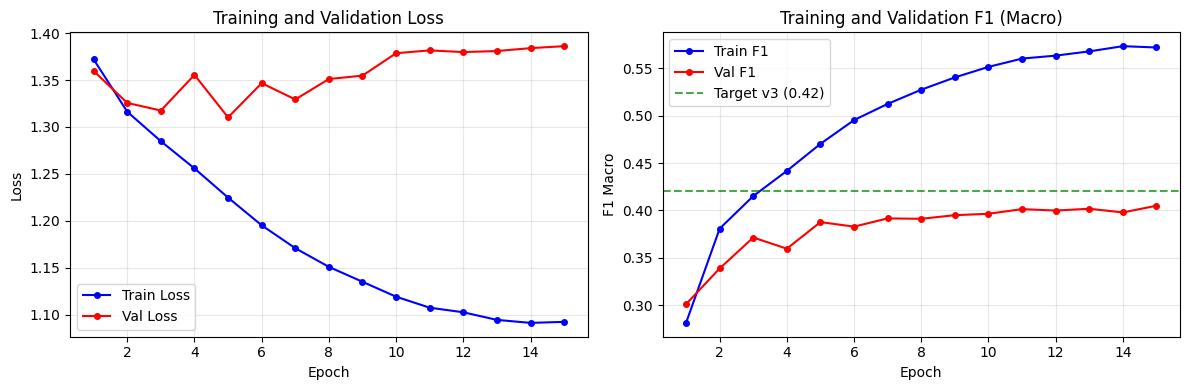

Training curves saved.


In [10]:
# ── Cell 9: Training curves ───────────────────────────────────────
import matplotlib.pyplot as plt

epochs    = [e['epoch']     for e in training_log]
train_f1s = [e['train_f1']  for e in training_log]
val_f1s   = [e['val_f1']    for e in training_log]
train_losses = [e['train_loss'] for e in training_log]
val_losses   = [e['val_loss']   for e in training_log]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, train_losses, 'b-o', label='Train Loss', markersize=4)
ax1.plot(epochs, val_losses,   'r-o', label='Val Loss',   markersize=4)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, train_f1s, 'b-o', label='Train F1', markersize=4)
ax2.plot(epochs, val_f1s,   'r-o', label='Val F1',   markersize=4)
ax2.axhline(y=0.42, color='g', linestyle='--', alpha=0.7, label='Target v3 (0.42)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('F1 Macro')
ax2.set_title('Training and Validation F1 (Macro)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/checkpoint/training_curves.png', dpi=150)
plt.show()
print('Training curves saved.')

In [11]:
# ── Cell 10: Final classification report ─────────────────────────
print('Final validation set performance (best checkpoint):')
print(classification_report(
    val_labels, val_preds,
    target_names=['true', 'false', 'misleading', 'unverifiable'],
    zero_division=0
))
print(f'Best val F1 macro: {best_val_f1:.4f} (epoch {best_epoch})')

Final validation set performance (best checkpoint):
              precision    recall  f1-score   support

        true       0.52      0.50      0.51      1110
       false       0.58      0.49      0.53      1165
  misleading       0.40      0.39      0.40       876
unverifiable       0.14      0.28      0.18       243

    accuracy                           0.45      3394
   macro avg       0.41      0.41      0.40      3394
weighted avg       0.48      0.45      0.46      3394

Best val F1 macro: 0.4049 (epoch 15)


In [12]:
# ── Cell 11: Download checkpoint ─────────────────────────────────
# Zips checkpoint folder and downloads to your machine.
# Save the .zip — you'll extract it to ~/verif-ai/models/verifai-classifier/

import shutil
shutil.make_archive('/content/verifai_checkpoint', 'zip', '/content/checkpoint')

from google.colab import files
files.download('/content/verifai_checkpoint.zip')
print('Download started. Extract to ~/verif-ai/models/verifai-classifier/')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started. Extract to ~/verif-ai/models/verifai-classifier/
